# 🔍 Diagnóstico: por que não usar features do mesmo ano do resultado

Este notebook mostra, com números, que várias colunas da Gold são **versões
diretas ou indiretas da própria `taxa_alfabetizacao`** do ano. Um classificador
treinado com elas parece excelente, mas só porque está "vendo a resposta" —
não serve na prática (o gestor precisaria já saber o resultado da prova).

É a justificativa metodológica para o modelo final (`03b`) usar **apenas
features do ano anterior**.

**Como usar na reunião:** roda célula por célula, lendo o texto antes de cada uma.


In [1]:
import sys; sys.path.append("..")
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")

from src import config
from src.preprocessing.gold_consumer import load_gold

df = load_gold(config.GOLD_DATASET)
print("Gold oficial da Fase 2:", df.shape, "| anos:", sorted(df.ano.unique()))
df.columns.tolist()


2026-09-05 12:46:15 [INFO] Usando cache local: data\gold\indicador_municipio.parquet


Gold oficial da Fase 2: (11030, 18) | anos: [np.int64(2023), np.int64(2024)]


['id_municipio',
 'taxa_alfabetizacao',
 'media_portugues',
 'taxa_meta_base',
 'meta_2024',
 'meta_2025',
 'meta_2026',
 'meta_2027',
 'meta_2028',
 'meta_2029',
 'meta_2030',
 'nivel_alfabetizacao',
 'percentual_participacao',
 'meta_ano_vigente',
 'diferenca_meta',
 'bateu_meta_2030',
 'classificacao',
 'ano']

## 1. `media_portugues` é quase o próprio resultado

`taxa_alfabetizacao` e `media_portugues` saem da **mesma edição da prova, no
mesmo ano**. A correlação beira 1.


corr(media_portugues, taxa_alfabetizacao) = 0.926


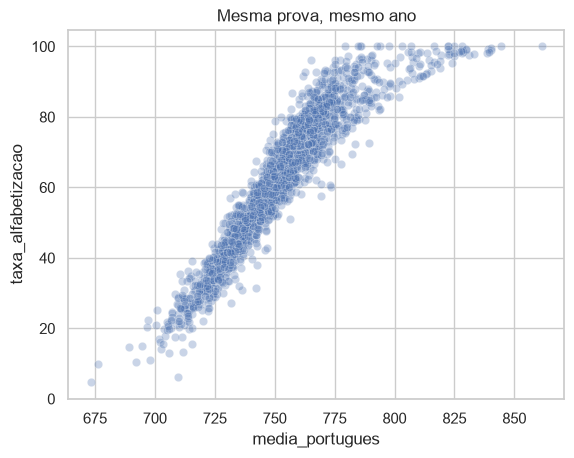

In [2]:
corr = df["media_portugues"].corr(df["taxa_alfabetizacao"])
print(f"corr(media_portugues, taxa_alfabetizacao) = {corr:.3f}")
sns.scatterplot(data=df.sample(2000, random_state=1), x="media_portugues", y="taxa_alfabetizacao", alpha=.3)
plt.title("Mesma prova, mesmo ano"); plt.show()


## 2. `taxa_meta_base` é a própria taxa do município

`taxa_meta_base` é o ponto de partida usado para construir a trajetória de
metas — na prática, a taxa do município. Correlação ~1 com o resultado.


In [3]:
print(f"corr(taxa_meta_base, taxa_alfabetizacao) = {df['taxa_meta_base'].corr(df['taxa_alfabetizacao']):.3f}")
print(f"erro médio |taxa_meta_base - taxa_alfabetizacao| = {(df.taxa_meta_base - df.taxa_alfabetizacao).abs().mean():.2f} p.p.")


corr(taxa_meta_base, taxa_alfabetizacao) = 0.983
erro médio |taxa_meta_base - taxa_alfabetizacao| = 1.19 p.p.


## 3. Colunas explicitamente derivadas do alvo

`diferenca_meta`, `classificacao`, `bateu_meta_2030` e `nivel_alfabetizacao`
são **calculadas a partir da `taxa_alfabetizacao`** frente às metas. Usá-las
como feature é entregar o gabarito.


In [4]:
d = df[df.ano == 2024].dropna(subset=["meta_ano_vigente"])
# diferenca_meta = taxa - meta_ano_vigente ?
print("diferenca_meta ≈ taxa - meta_ano_vigente? erro médio:",
      (d.diferenca_meta - (d.taxa_alfabetizacao - d.meta_ano_vigente)).abs().mean().round(3))
# classificacao é função direta dessa diferença
print()
print(d.groupby("classificacao").agg(
    dif_min=("diferenca_meta", "min"), dif_max=("diferenca_meta", "max"), n=("diferenca_meta", "size")))
print()
print("nivel_alfabetizacao x taxa (níveis são faixas da própria taxa):")
print(df.assign(nivel=pd.to_numeric(df.nivel_alfabetizacao, errors="coerce"))
        .groupby("nivel").taxa_alfabetizacao.agg(["min", "max", "mean"]).round(1))


diferenca_meta ≈ taxa - meta_ano_vigente? erro médio: 0.0

                      dif_min  dif_max     n
classificacao                               
Abaixo da meta           -5.0    -0.01   761
Acima da meta             5.0    84.27  2063
Muito abaixo da meta    -68.9    -5.01  1647
Na meta                   0.0     4.98   761

nivel_alfabetizacao x taxa (níveis são faixas da própria taxa):
        min    max  mean
nivel                   
0.0     4.4   73.4  32.0
1.0    25.8   71.8  46.3
2.0    32.9   91.7  55.7
3.0    39.7   83.9  65.2
4.0    51.2   89.2  74.7
5.0    43.4  100.0  88.1


## 4. As metas embutem a trajetória histórica do município

`meta_2024`…`meta_2030` são calculadas a partir de `taxa_meta_base` até chegar
a 80% em 2030 — ou seja, são uma transformação da taxa do próprio município.


In [5]:
metas = [f"meta_{a}" for a in range(2024, 2031)]
print(df[metas].corrwith(df["taxa_alfabetizacao"]).round(3))


meta_2024    0.796
meta_2025    0.791
meta_2026    0.789
meta_2027    0.788
meta_2028    0.788
meta_2029    0.791
meta_2030      NaN
dtype: float64


## 5. A prova: mesmo ano vs. defasado

Mesmo target (`em_risco` = abaixo da média nacional), mesma validação
(`GroupKFold` por UF). Só muda de onde vêm as features.


In [6]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, GroupKFold
from src.preprocessing.features import build_lagged_frame, ref_nacional_por_ano

ref = ref_nacional_por_ano(load_gold(config.GOLD_REF_NACIONAL))

# (a) MESMO ANO — features contemporâneas ao resultado
g = df.copy()
g["cod_uf"] = g.id_municipio.astype(str).str.zfill(7).str[:2].astype(int)
g["ref"] = g.ano.map(ref)
g = g.dropna(subset=["ref"])
g["em_risco"] = (g.taxa_alfabetizacao < g.ref).astype(int)
g["nivel_num"] = pd.to_numeric(g.nivel_alfabetizacao, errors="coerce")
LEAK = ["media_portugues", "taxa_meta_base", "nivel_num", "percentual_participacao",
        "meta_2024", "meta_2025", "meta_2026"]
rf = Pipeline([("i", SimpleImputer(strategy="median")),
               ("m", RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=10,
                                            class_weight="balanced", random_state=42, n_jobs=-1))])
r_leak = cross_validate(rf, g[LEAK], g.em_risco, groups=g.cod_uf, cv=GroupKFold(5),
                        scoring=["roc_auc", "average_precision", "recall"], n_jobs=-1)

# (b) DEFASADO — só features do ano anterior (o modelo do 03b)
frame = build_lagged_frame(df, ref)
r_lag = cross_validate(rf, frame[config.FEATURE_COLS], frame[config.TARGET_COL],
                       groups=frame[config.GROUP_COL], cv=GroupKFold(5),
                       scoring=["roc_auc", "average_precision", "recall"], n_jobs=-1)

print(f"MESMO ANO (vazado): ROC-AUC {r_leak['test_roc_auc'].mean():.3f} | "
      f"PR-AUC {r_leak['test_average_precision'].mean():.3f} | recall {r_leak['test_recall'].mean():.3f}")
print(f"DEFASADO (honesto): ROC-AUC {r_lag['test_roc_auc'].mean():.3f} | "
      f"PR-AUC {r_lag['test_average_precision'].mean():.3f} | recall {r_lag['test_recall'].mean():.3f}")
print("\nA diferença (~0,99 vs ~0,82) é o tamanho do vazamento.")


2026-09-05 12:46:16 [INFO] Usando cache local: data\gold\painel_nacional.parquet


MESMO ANO (vazado): ROC-AUC 0.996 | PR-AUC 0.993 | recall 0.974
DEFASADO (honesto): ROC-AUC 0.822 | PR-AUC 0.749 | recall 0.713

A diferença (~0,99 vs ~0,82) é o tamanho do vazamento.


## 6. Resumo — colunas por risco de vazamento

| Grupo | Colunas | Risco | Uso no modelo |
|---|---|---|---|
| Mesma prova / mesmo ano | `media_portugues`, `taxa_meta_base` | **Crítico** — quase o próprio alvo | ❌ nunca do mesmo ano |
| Derivadas do alvo | `diferenca_meta`, `classificacao`, `bateu_meta_2030`, `nivel_alfabetizacao` | **Crítico** — cálculo direto da taxa | ❌ nunca |
| Metas do programa | `meta_2024`…`meta_2030` | **Alto** — transformação da taxa-base do município | ⚠️ só como referência/threshold, não feature |
| Participação | `percentual_participacao` | Baixo | ✅ (defasada) |
| Desempenho passado | `*_ant` (LAG) | Baixo — anterior ao resultado | ✅ é o que o `03b` usa |

**Conclusão:** o único sinal genuíno e utilizável é o **desempenho do próprio
município no ano anterior**. É modesto (ROC-AUC ~0,82), mas real.
